In [1]:
import torch
words = open('names.txt', 'r').read().splitlines()

In [2]:
len(words)
type(words)
ch = words[3]
ch

'isabella'

In [3]:
words[:3]

['emma', 'olivia', 'ava']

In [18]:
# for w in words:
#     for ch1, ch2 in zip(w,w[1:]):
#         print(ch1,ch2)

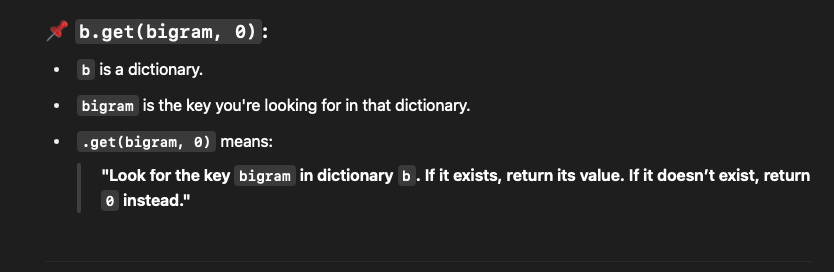

In [4]:
b = {}
for w in words:
  chs = ['<S>'] + list(w) + ['<E>'] ## Initializing start and end tokens for now Converts the word into a list of characters, and prepends '<S>' and appends '<E>' to mark the start and end of the word respectively.
  for ch1, ch2 in zip(chs, chs[1:]):
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1

In [69]:
## Trigram try
T = torch.zeros((27, 27,27), dtype=torch.int32)

for w in words:
  chs = ['.'] + list(w) + ['.'] ## Updating the start and end token since if we use separate tokens for start and end then we will have a row of bigrams ending with start token and a row of bigrams starting with end token with frquency 0 since start cannot end and end cannot start. P.S needs to be updated
  for ch1, ch2, ch3 in zip(chs, chs[1:],chs[2:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    ix3 = stoi[ch3]
    T[ix1, ix2, ix3] += 1

In [71]:
T.shape

torch.Size([27, 27, 27])

In [77]:

##start_ix = stoi['a']  # Index for start token

# Extract the slice: all trigrams that begin with start token '.'
##T_slice = T[start_ix]  # Shape: (27, 27)
##for i in range(27):
##    for j in range(27):
##        count = T[start_ix, i, j].item()
##        if count > 0:
##           chstr = itos[start_ix] + itos[i] + itos[j]
##            plt.text(j, i, f'{chstr}\n{count}', ha="center", va="center", color='gray')
##plt.axis('off')
##plt.show()

In [85]:
## if any [ix1, ix2, :] slice in your data was all zeros (meaning that trigram was never observed), then t[ix1, ix2, :] will become all zeros divided by zero, leading to all NaNs in that slice.
## When you later try to draw a sample using torch.multinomial, you get the error because probabilities must be numbers between 0 and 1, summing to 1.
## How to fix
## You need to handle zero-count trigrams before normalizing!
## 1. Add a smoothing step (Laplace smoothing)
## Before normalization, add 1 to every trigram count to avoid zero-division and ensure every slice has positive probability:
T = T + 1        # Add one to every trigram count
t = T.float()
t /= t.sum(dim=2, keepdim=True)  # Now normalization will not produce NaNs

In [86]:
g = torch.Generator().manual_seed(28399788845745)
for i in range(30):
    out = []
    # Start with two start tokens
    ix1 = 0  # Typically index 0 is '.'
    ix2 = 0
    while True:
        # Get the probability distribution for next character
        p = t[ix1, ix2]
        ix3 = torch.multinomial(p, 1, replacement=True, generator=g).item()
        out.append(itos[ix3])
        if ix3 == 0:  # End token
            print(''.join(out))
            break
        # Slide window: previous two indices for context
        ix1, ix2 = ix2, ix3


xawnximaelinaounna.
fer.
fedy.
zyia.
oseed.
jasharya.
quadielvpalveyly.
iroce.
xava.
na.
vismary.
grayn.
xty.
rassamya.
jer.
waorizyvqoztddawree.
topielyna.
ibbom.
un.
yet.
yin.
tapqqkvklynn.
teviraeline.
saleah.
wellynna.
whmi.
zuqsmarefcnzia.
jame.
sanajia.
jeraromcoli.


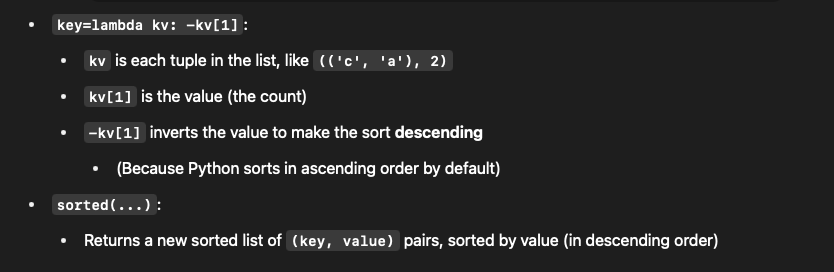

In [19]:
#sorted(b.items(), key = lambda kv: -kv[1])

In [5]:
N = torch.zeros((27, 27), dtype=torch.int32)

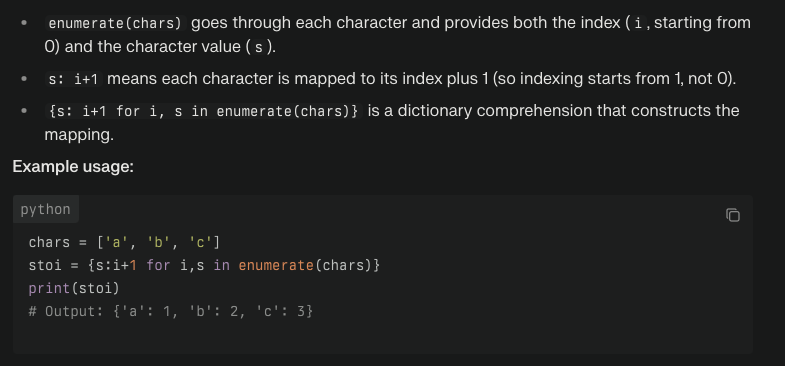

In [49]:
chars = sorted(list(set(''.join(words)))) ## Combining all the words into a string and then into a set so only unqiue values remain then sorting it to create a character to index mapping
stoi = {s:i+1 for i,s in enumerate(chars)} ## since we are setting "." token as mapped to int 0 so we start from 1
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [50]:
for w in words:
  chs = ['.'] + list(w) + ['.'] ## Updating the start and end token since if we use separate tokens for start and end then we will have a row of bigrams ending with start token and a row of bigrams starting with end token with frquency 0 since start cannot end and end cannot start. P.S needs to be updated
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

In [51]:
import matplotlib.pyplot as plt
%matplotlib inline



In [52]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

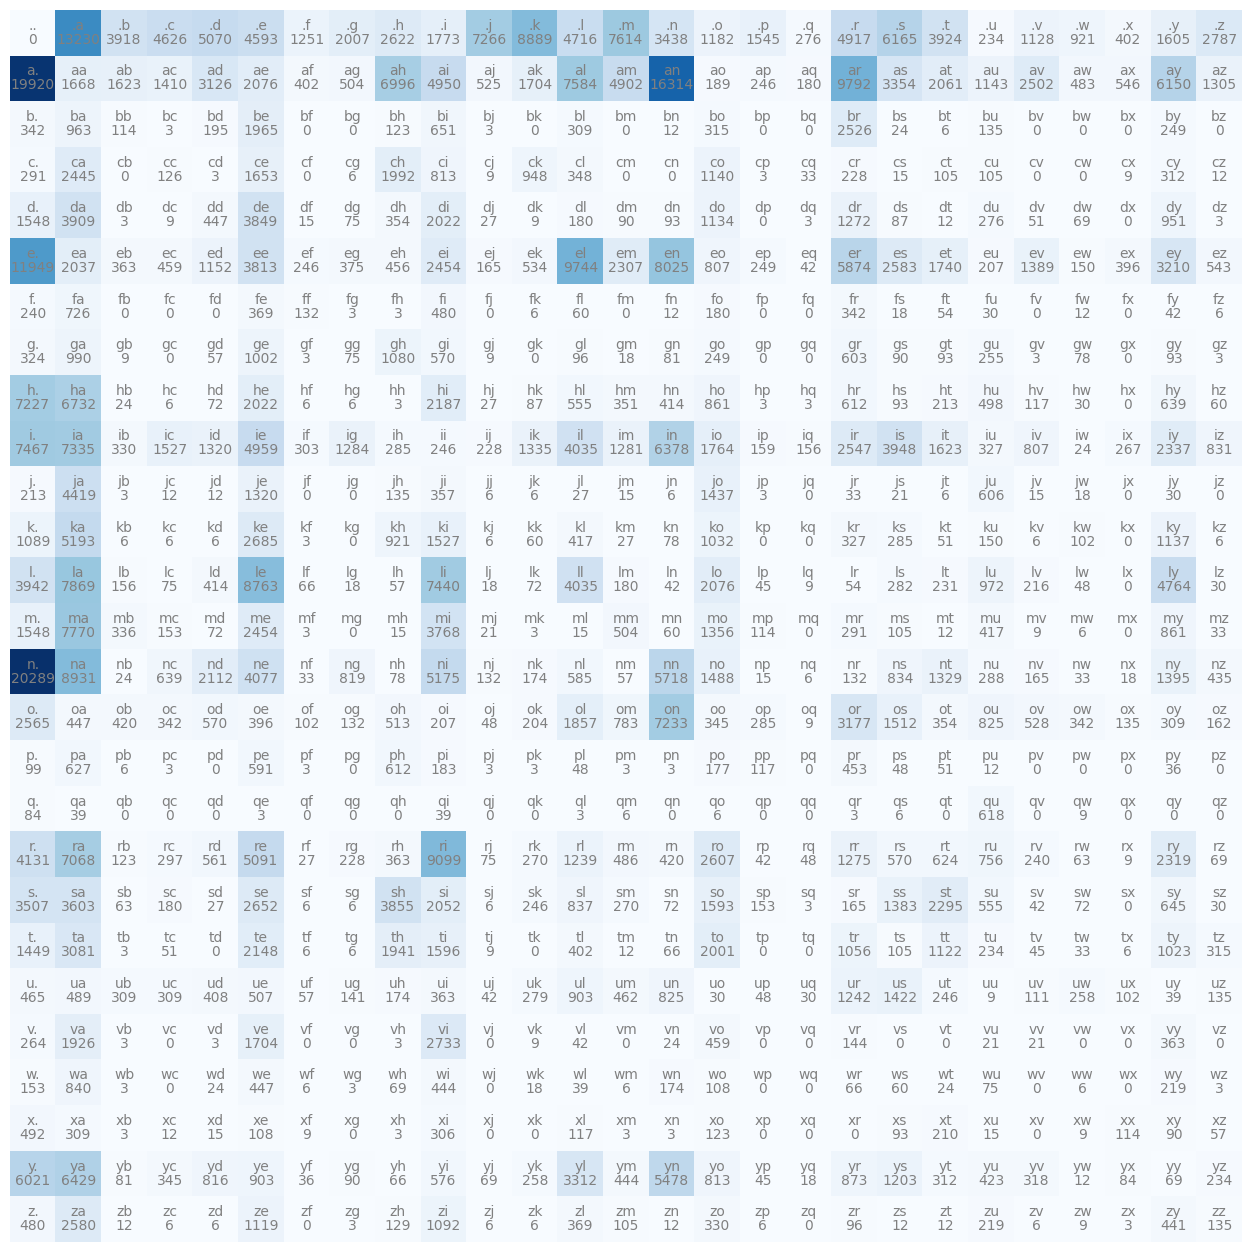

In [53]:
plt.show()

In [54]:
print(type(N[2,2]))
print(type(N[2,2].item()))
print(N[2,2])
print(N[2,2].item())

<class 'torch.Tensor'>
<class 'int'>
tensor(114, dtype=torch.int32)
114


In [12]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [55]:
## Normalizing the Array in order to get a probability distribution 
p = N[0]
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [14]:
B = N.float()
B=B/B.sum(-1,keepdim=True)
B[4].sum()

tensor(1.0000)

In [15]:
## Sampling from the probability distribution 
g = torch.Generator().manual_seed(28399788845745)
q = torch.rand(3,generator=g)
q


tensor([0.7805, 0.6977, 0.5654])

tensor(1.0000)

In [16]:
idx = torch.multinomial(p,1,replacement=True,generator=g)
p[idx]

tensor([0.0792])

In [34]:
## Sampling from bi-model
## We start by sampling a single character from the first row giving us a probability of each character occuring as the first character of
## the word. Then while we dont hit the end of word token, we move to the row of the character we are currently at and then random sample 
## the next character from the probability list.
g = torch.Generator().manual_seed(28399788845745)
for i in range(30):
    out=[]
    ix=0
    while True:
        p=B[ix].float()
        ## p = torch.ones(27)/27.0 ##untrained model
        # p=p/p.sum()
        ix = torch.multinomial(p,1,replacement=True,generator=g).item()
        ##print(itos[ix])
        out.append(itos[ix])
        if ix == 0:
            print(out)
            break

['c', 'h', 'w', 'u', 'x', 'i', 'r', 'i', 'e', 'l', 'i', '.']
['r', 'o', 'u', 'n', 'n', 'a', 'w', 'a', 'n', '.']
['x', 'f', 'e', 'y', 'c', 't', 'a', 'y', 'i', 'k', 'e', 'o', 'u', 'x', 'x', 'x', '.']
['j', 'a', 's', 'h', 'a', 'r', 'o', 'o', 'o', 'n', '.']
['z', 'o', 'n', '.']
['k', 'v', 'a', '.']
['k', 'y', 'l', 'y', 'l', 'y', '.']
['a', 'r', 'o', 'u', 'e', 's', 't', 'a', 'b', 'r', 'a', 'n', 'a', 'm', 'i', 'g', 'e', 'm', 'a', 'r', 'y', '.']
['r', 'i', 'n', '.']
['n', '.']
['j', 'a', 'l', '.']
['r', 'a', 's', 'o', 'n', 'o', 'n', 'a', 'e', 'n', 'e', 'r', 'i', 'a', 'r', 'o', 'r', 'i', 'z', 'y', 'v', 'i', 'o', '.']
['t', 'h', 'l', 'a', 't', 'r', 'e', 'e', 'r', 't', 'o', 'p', 'i', 'e', 'l', 'e', '.']
['a', 'r', 'i', 'b', 'b', 'r', 'e', '.']
['j', '.']
['h', 'a', 'l', 't', '.']
['y', 'i', 'n', '.']
['t', 'a', 'h', '.']
['k', 'e', 's', 'k', 'l', 'y', 'n', 'n', '.']
['t', 'e', 'v', 'i', 'r', 'a', 's', 't', 'i', '.']
['s', 'h', '.']
['s', 'l', 'e', 'l', 'e', 'e', 'a', 'l', 'l', 'l', 'y', 'a', 'u'

In [18]:
B = N

In [52]:
B.sum()

tensor(228146)

In [19]:
B.sum(0,keepdim=True)

tensor([[32033, 33885,  2645,  3532,  5496, 20423,   905,  1927,  7616, 17701,
          2900,  5040, 13958,  6642, 18327,  7934,  1026,   272, 12700,  8106,
          5570,  3135,  2573,   929,   697,  9776,  2398]])

In [56]:
P=N.float()
P/=P.sum(1,keepdims=True)

In [57]:

for i in range (30):
    out=[]
    ix=0
    while True:
        p=P[ix]
        ## p = torch.ones(27)/27.0 ##untrained model
        # p=p/p.sum()
        ix = torch.multinomial(p,1,replacement=True,generator=g).item()
        ##print(itos[ix])
        out.append(itos[ix])
        if ix == 0:
            print(out)
            break

['y', 'r', 'e', 's', 'i', 's', 'h', 'a', 'n', 'a', '.']
['c', 'a', 'z', 'y', 'l', 'y', 'k', 'e', 'r', 'r', 'a', 'r', 'i', 'c', 'i', 'r', 'y', 'a', 'n', 'n', 'o', 'n', 'e', 'e', 'y', 'a', 'n', '.']
['g', 'a', 'm', 'a', 'n', 'd', 'y', '.']
['d', 'a', 'n', '.']
['m', 'm', 'e', 'd', 'a', 'r', 'l', 'i', '.']
['c', 'o', '.']
['r', 'i', 'a', 'v', 'a', 't', 'r', 'e', 'm', 'e', 'i', 'e', 'l', 'i', 'n', '.']
['j', 'e', 'e', 'i', 'y', 'r', 'i', 'n', 'v', 'i', 'o', 'n', 'a', '.']
['j', 'e', '.']
['g', 'o', 'n', '.']
['t', 'o', 'u', 'u', 'j', 'u', 'n', 'a', 'n', 'z', 'a', 'r', 'k', 'o', 'l', '.']
['k', 'e', 'z', 'o', 'r', 'i', 'g', 'o', 'u', 'i', 'e', 'v', 'e', 'e', '.']
['d', 'a', '.']
['r', 'o', 'c', 'o', 'n', '.']
['c', 'e', 'r', 'i', 'y', 'l', 'i', 'l', 'a', 'l', 'o', 'n', '.']
['n', 'i', 'a', 'x', 'a', 'n', 'a', 'a', '.']
['s', 'i', 'g', 'h', 'a', '.']
['s', 'h', 'i', 'l', 'o', 'n', 'z', 'i', '.']
['a', 'n', 'g', 'n', '.']
['a', '.']
['i', 'a', 'h', 'i', 'a', 'k', 'h', 'a', '.']
['k', 'a', 'l'

In [97]:
## Now we need to build a loss function to see how good our model is 
## Maximum Likehood Estimiation 
## log(a*b*c) = log(a) + log(b) + logc(c)
## GOAL: maximize likehood of data w.r.t model parameters (Statistical Modeling)
## Equivalent to maximixing the log likelihood (Log is a monotonic function )
## Equivalent to minizing the normalized negative log likelihood

In [110]:
log_likelihood = 0.0
count =0
for word in words:
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        log_likelihood+=torch.log(P[ix1,ix2])
        count+=1
        prob = P[ix1,ix2] ## in the normalized bigram mode the probability of ix2 following ix1
        ##print(f'{ch1}{ch2}: {prob:.8f}')

print(f'Log-LikeLihood is: {log_likelihood}')
## here we use negative log-likelihood since by meaning of the word loss, it should reduce when our model is more accurate and increase when its not
print(f'Negative Log-LikeLihood is: {-log_likelihood}')

print(f'Normalized Negative Log-LikeLihood is: {-log_likelihood/count}')

Log-LikeLihood is: -559891.75
Negative Log-LikeLihood is: 559891.75
Normalized Negative Log-LikeLihood is: 2.454094171524048


### Now the thing to notice here is since we have 27 character and if we at begin assume equal probability  of each character following another then 1/27.0 will be roughly 0.037. So anytime the probability in our bigram model is above 0.037 then it means it has learned

In [62]:
1/27.0


0.037037037037037035

In [112]:
log_likelihood = 0.0
count =0
for word in words: ## Can try with normal names to see for word in ["gaurav"]
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2,ch3 in zip(chs,chs[1:],chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        log_likelihood+=torch.log(t[ix1,ix2,ix3]) 
        count+=1
        prob = T[ix1,ix2,ix3] ## in the normalized bigram mode the probability of ix2 following ix1
        ##print(f'{ch1}{ch2}: {prob:.8f}')

print(f'Log-LikeLihood is: {log_likelihood}')
## here we use negative log-likelihood since by meaning of the word loss, it should reduce when our model is more accurate and increase when its not
print(f'Negative Log-LikeLihood is: {-log_likelihood}')

print(f'Normalized Negative Log-LikeLihood is: {-log_likelihood/count}')

Log-LikeLihood is: -410414.96875
Negative Log-LikeLihood is: 410414.96875
Normalized Negative Log-LikeLihood is: 2.092747449874878
